# GapClean Visualization Tutorial

This notebook demonstrates how to use GapClean's Python API and visualize the results using WebLogo and other tools.

## Installation

First, install required packages:

In [ ]:
# Uncomment to install required packages
# !pip install gapclean weblogo matplotlib pandas biopython plotly

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from Bio import SeqIO
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import subprocess

# Import GapClean's high-level API
from gapclean import clean_alignment

# Create output directory
output_dir = Path('gapclean_output')
output_dir.mkdir(exist_ok=True)

## 1. Create Sample Alignment

Let's create a sample protein alignment with gaps to demonstrate GapClean.

In [2]:
# Create a sample alignment
sample_alignment = """>Sequence1
MTKL--IPQVLSDG----HFKLPQVLASDG--WITKLASD
>Sequence2
MTKLAPIPQVLSDGERTYHFKLPQVLASDG--WITKLASD
>Sequence3
MTKL--IPQVLSDG----HFKLPQVLASDGTYWITKLASD
>Sequence4
MTKLAPIPQVLSDGERTY--KLPQVLASDG--WITKLASD
>Sequence5
MTKL--IPQVLSDG----HFKLPQVLASDG--WITKLASD
>Sequence6
MTKLAPIPQVLSDGERTYHFKLPQVLASDGTYWITKLASD
>Sequence7
MTKL--IPQVLSDG----HFKLPQVLASDG--WITKLASD
>Sequence8
MTKLAPIPQVLSDGERTY--KLPQVLASDGTYWITKLASD
"""

# Save to file
input_file = output_dir / 'sample_alignment.fa'
with open(input_file, 'w') as f:
    f.write(sample_alignment)

print(f"Created sample alignment: {input_file}")
print(f"Number of sequences: {sample_alignment.count('>')}")

Created sample alignment: gapclean_output/sample_alignment.fa
Number of sequences: 8


## 2. Alignment Statistics Helper

Create a helper function to analyze alignment statistics for visualization.

In [3]:
def analyze_alignment(fasta_file):
    """Analyze alignment statistics for visualization."""
    sequences = list(SeqIO.parse(fasta_file, 'fasta'))
    
    if not sequences:
        return None
    
    n_seqs = len(sequences)
    aln_length = len(sequences[0].seq)
    
    # Count gaps per column
    gap_counts = []
    for pos in range(aln_length):
        col = [str(seq.seq[pos]) for seq in sequences]
        n_gaps = col.count('-') + col.count('.')
        gap_counts.append(n_gaps / n_seqs * 100)
    
    # Overall gap percentage
    total_chars = n_seqs * aln_length
    total_gaps = sum([str(seq.seq).count('-') + str(seq.seq).count('.') for seq in sequences])
    overall_gap_pct = total_gaps / total_chars * 100
    
    return {
        'n_sequences': n_seqs,
        'alignment_length': aln_length,
        'overall_gap_percentage': overall_gap_pct,
        'gap_counts_per_column': gap_counts,
        'columns_with_50pct_gaps': sum(1 for g in gap_counts if g > 50),
        'columns_with_75pct_gaps': sum(1 for g in gap_counts if g > 75),
    }

# Analyze original alignment
original_stats = analyze_alignment(input_file)

print("\n=== Original Alignment Statistics ===")
print(f"Number of sequences: {original_stats['n_sequences']}")
print(f"Alignment length: {original_stats['alignment_length']}")
print(f"Overall gap percentage: {original_stats['overall_gap_percentage']:.1f}%")
print(f"Columns with >50% gaps: {original_stats['columns_with_50pct_gaps']}")
print(f"Columns with >75% gaps: {original_stats['columns_with_75pct_gaps']}")


=== Original Alignment Statistics ===
Number of sequences: 8
Alignment length: 40
Overall gap percentage: 11.9%
Columns with >50% gaps: 2
Columns with >75% gaps: 0


## 3. Run GapClean with Different Modes

### 3.1 Threshold Mode (Remove columns with >50% gaps)

In [4]:
# Run GapClean with threshold mode
threshold_output = output_dir / 'cleaned_threshold50.fa'

stats = clean_alignment(
    input_file=str(input_file),
    output_file=str(threshold_output),
    threshold=50
)

print(f"\n=== Threshold Cleaning Results ===")
print(f"Alignment length: {stats['output_length']} (was {stats['input_length']})")
print(f"Columns removed: {stats['columns_removed']}")
print(f"Time taken: {stats['elapsed_seconds']:.2f} seconds")

# Analyze for visualization
threshold_stats = analyze_alignment(threshold_output)

[GAPCLEAN] Number of Sequences = 8,
[GAPCLEAN] Alignment Length = 40,
[GAPCLEAN] row_chunk_size = 5000,
[GAPCLEAN] col_chunk_size = 5000 

[GAPCLEAN] Removing columns with > 50% gaps.



[GAPCLEAN] Cleaning gaps: 100%|██████████| 40/40 [00:00<00:00, 88909.46cols/s]


[GAPCLEAN] Final alignment length: 38 columns (was 40)


=== Threshold Cleaning Results ===
Alignment length: 38 (was 40)
Columns removed: 2
Time taken: 0.09 seconds


### 3.2 Seed Mode (Remove gaps relative to first sequence)

In [5]:
# Run GapClean with seed mode
seed_output = output_dir / 'cleaned_seed.fa'

stats = clean_alignment(
    input_file=str(input_file),
    output_file=str(seed_output),
    seed_index=0
)

print(f"\n=== Seed Cleaning Results ===")
print(f"Alignment length: {stats['output_length']} (was {stats['input_length']})")
print(f"Columns removed: {stats['columns_removed']}")

# Analyze for visualization
seed_stats = analyze_alignment(seed_output)

[GAPCLEAN] Number of Sequences = 8,
[GAPCLEAN] Alignment Length = 40,
[GAPCLEAN] row_chunk_size = 5000,
[GAPCLEAN] col_chunk_size = 5000 

[GAPCLEAN] Removing columns with gaps in seed seq index=0.



[GAPCLEAN] Cleaning gaps: 100%|██████████| 40/40 [00:00<00:00, 277309.36cols/s]


[GAPCLEAN] Final alignment length: 32 columns (was 40)


=== Seed Cleaning Results ===
Alignment length: 32 (was 40)
Columns removed: 8


### 3.3 Entropy Mode (Keep conserved regions)

In [6]:
# Run GapClean with entropy-max mode (keep conserved)
entropy_output = output_dir / 'cleaned_entropy.fa'

stats = clean_alignment(
    input_file=str(input_file),
    output_file=str(entropy_output),
    entropy_max=2.0
)

print(f"\n=== Entropy Cleaning Results ===")
print(f"Alignment length: {stats['output_length']} (was {stats['input_length']})")
print(f"Columns removed: {stats['columns_removed']}")

# Analyze for visualization
entropy_stats = analyze_alignment(entropy_output)

[GAPCLEAN] Number of Sequences = 8,
[GAPCLEAN] Alignment Length = 40,
[GAPCLEAN] row_chunk_size = 5000,
[GAPCLEAN] col_chunk_size = 5000 

[GAPCLEAN] Removing columns with entropy > 2.0 bits (keep conserved regions).



[GAPCLEAN] Calculating entropy: 100%|██████████| 40/40 [00:00<00:00, 14930.33cols/s]


[GAPCLEAN] Average entropy: 0.238 bits
[GAPCLEAN] Removed 0 columns with entropy > 2.0



[GAPCLEAN] Cleaning gaps: 100%|██████████| 40/40 [00:00<00:00, 274137.52cols/s]


[GAPCLEAN] Final alignment length: 40 columns (was 40)


=== Entropy Cleaning Results ===
Alignment length: 40 (was 40)
Columns removed: 0


## 4. Visualize Gap Distribution

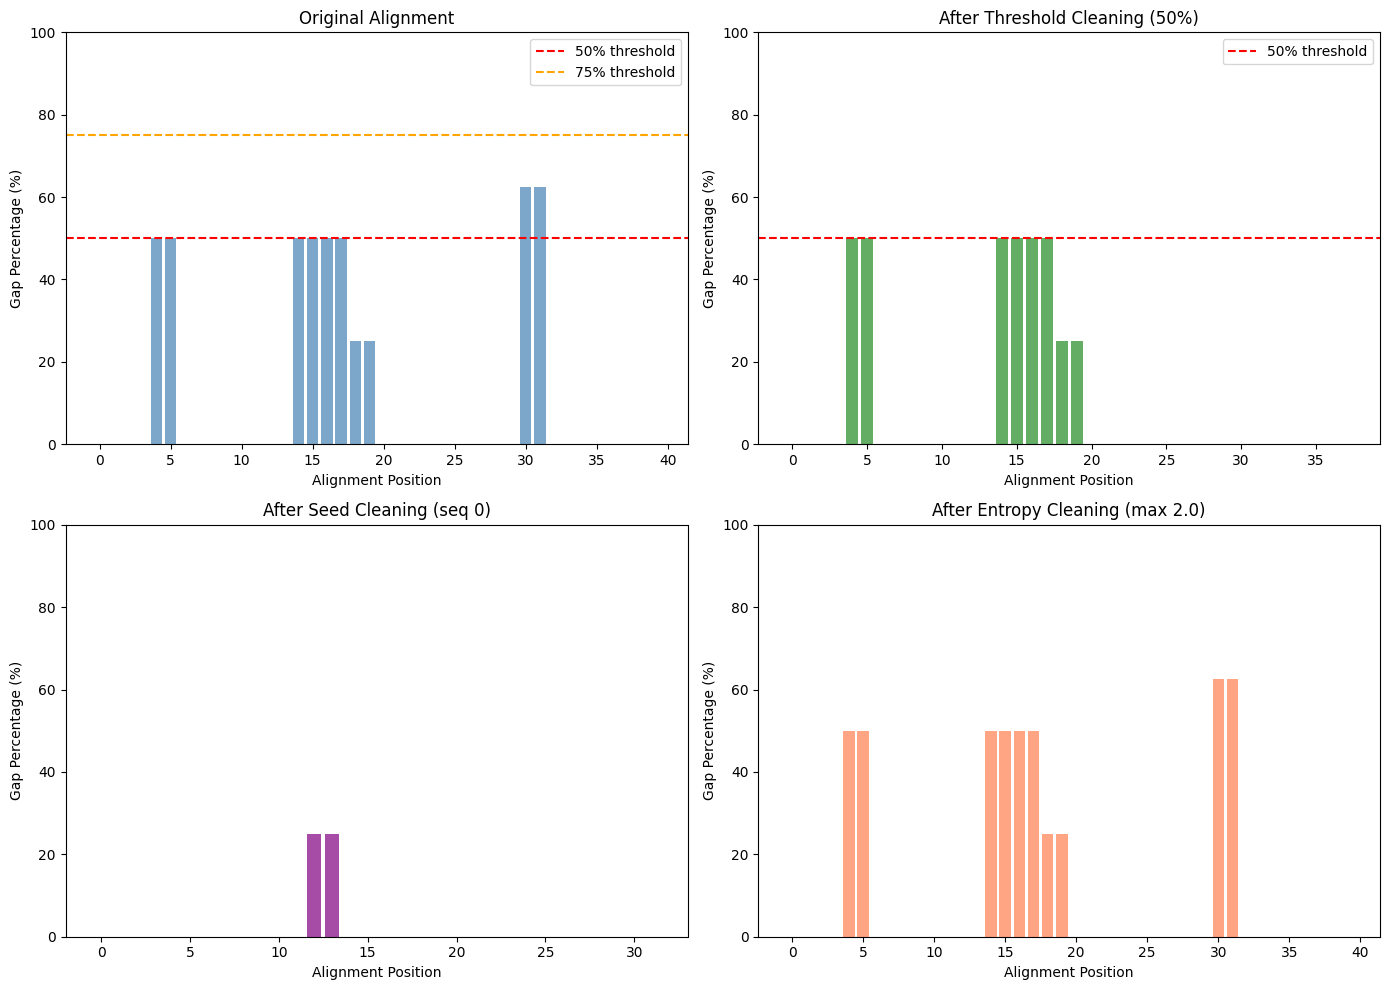

Gap distribution plot saved to: gapclean_output/gap_distribution.png


In [7]:
# Plot gap distribution across alignment positions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original alignment
axes[0, 0].bar(range(len(original_stats['gap_counts_per_column'])), 
               original_stats['gap_counts_per_column'], 
               color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=50, color='r', linestyle='--', label='50% threshold')
axes[0, 0].axhline(y=75, color='orange', linestyle='--', label='75% threshold')
axes[0, 0].set_title('Original Alignment')
axes[0, 0].set_xlabel('Alignment Position')
axes[0, 0].set_ylabel('Gap Percentage (%)')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 100)

# After threshold cleaning
axes[0, 1].bar(range(len(threshold_stats['gap_counts_per_column'])), 
               threshold_stats['gap_counts_per_column'], 
               color='forestgreen', alpha=0.7)
axes[0, 1].axhline(y=50, color='r', linestyle='--', label='50% threshold')
axes[0, 1].set_title('After Threshold Cleaning (50%)')
axes[0, 1].set_xlabel('Alignment Position')
axes[0, 1].set_ylabel('Gap Percentage (%)')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 100)

# After seed cleaning
axes[1, 0].bar(range(len(seed_stats['gap_counts_per_column'])), 
               seed_stats['gap_counts_per_column'], 
               color='purple', alpha=0.7)
axes[1, 0].set_title('After Seed Cleaning (seq 0)')
axes[1, 0].set_xlabel('Alignment Position')
axes[1, 0].set_ylabel('Gap Percentage (%)')
axes[1, 0].set_ylim(0, 100)

# After entropy cleaning
axes[1, 1].bar(range(len(entropy_stats['gap_counts_per_column'])), 
               entropy_stats['gap_counts_per_column'], 
               color='coral', alpha=0.7)
axes[1, 1].set_title('After Entropy Cleaning (max 2.0)')
axes[1, 1].set_xlabel('Alignment Position')
axes[1, 1].set_ylabel('Gap Percentage (%)')
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(output_dir / 'gap_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gap distribution plot saved to:", output_dir / 'gap_distribution.png')

## 5. Generate WebLogo Visualizations

WebLogo shows sequence conservation at each position.

In [8]:
def generate_weblogo(input_fasta, output_png, title='Sequence Logo'):
    """Generate WebLogo from FASTA alignment."""
    cmd = [
        'weblogo',
        '-f', str(input_fasta),
        '-o', str(output_png),
        '-F', 'png',
        '-A', 'protein',
        '--title', title,
        '--color-scheme', 'chemistry',
        '--size', 'large',
        '-U', 'bits'
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode == 0:
        print(f"WebLogo generated: {output_png}")
        return True
    else:
        print(f"Error generating WebLogo: {result.stderr}")
        return False

# Generate WebLogos
print("Generating WebLogo visualizations...\n")

generate_weblogo(input_file, 
                output_dir / 'weblogo_original.png',
                'Original Alignment')

generate_weblogo(threshold_output,
                output_dir / 'weblogo_threshold50.png', 
                'After Threshold Cleaning (50%)')

generate_weblogo(seed_output,
                output_dir / 'weblogo_seed.png',
                'After Seed Cleaning')

generate_weblogo(entropy_output,
                output_dir / 'weblogo_entropy.png',
                'After Entropy Cleaning')

Generating WebLogo visualizations...

WebLogo generated: gapclean_output/weblogo_original.png
WebLogo generated: gapclean_output/weblogo_threshold50.png
WebLogo generated: gapclean_output/weblogo_seed.png
WebLogo generated: gapclean_output/weblogo_entropy.png


True

## 6. Display WebLogos


=== Original Alignment ===


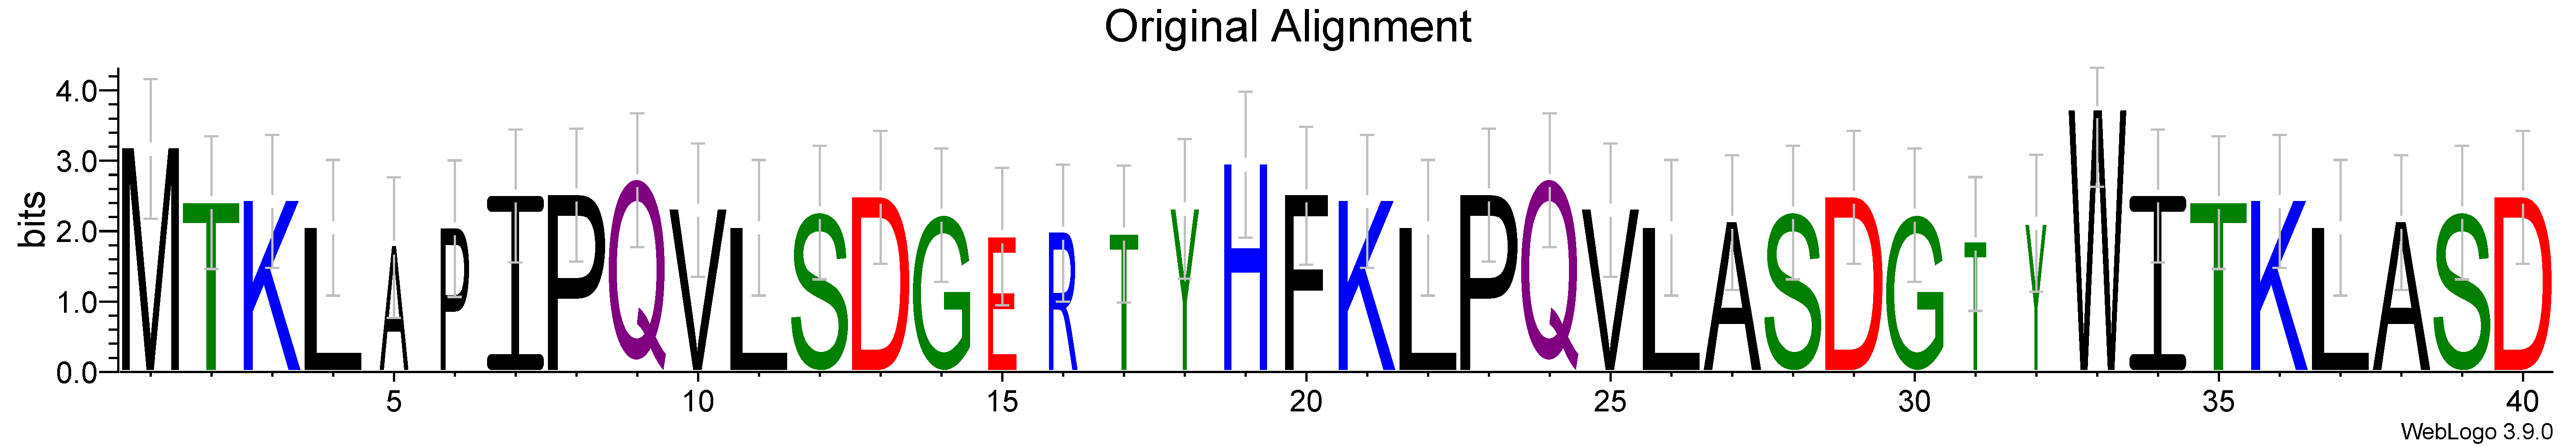


=== After Threshold Cleaning (50%) ===


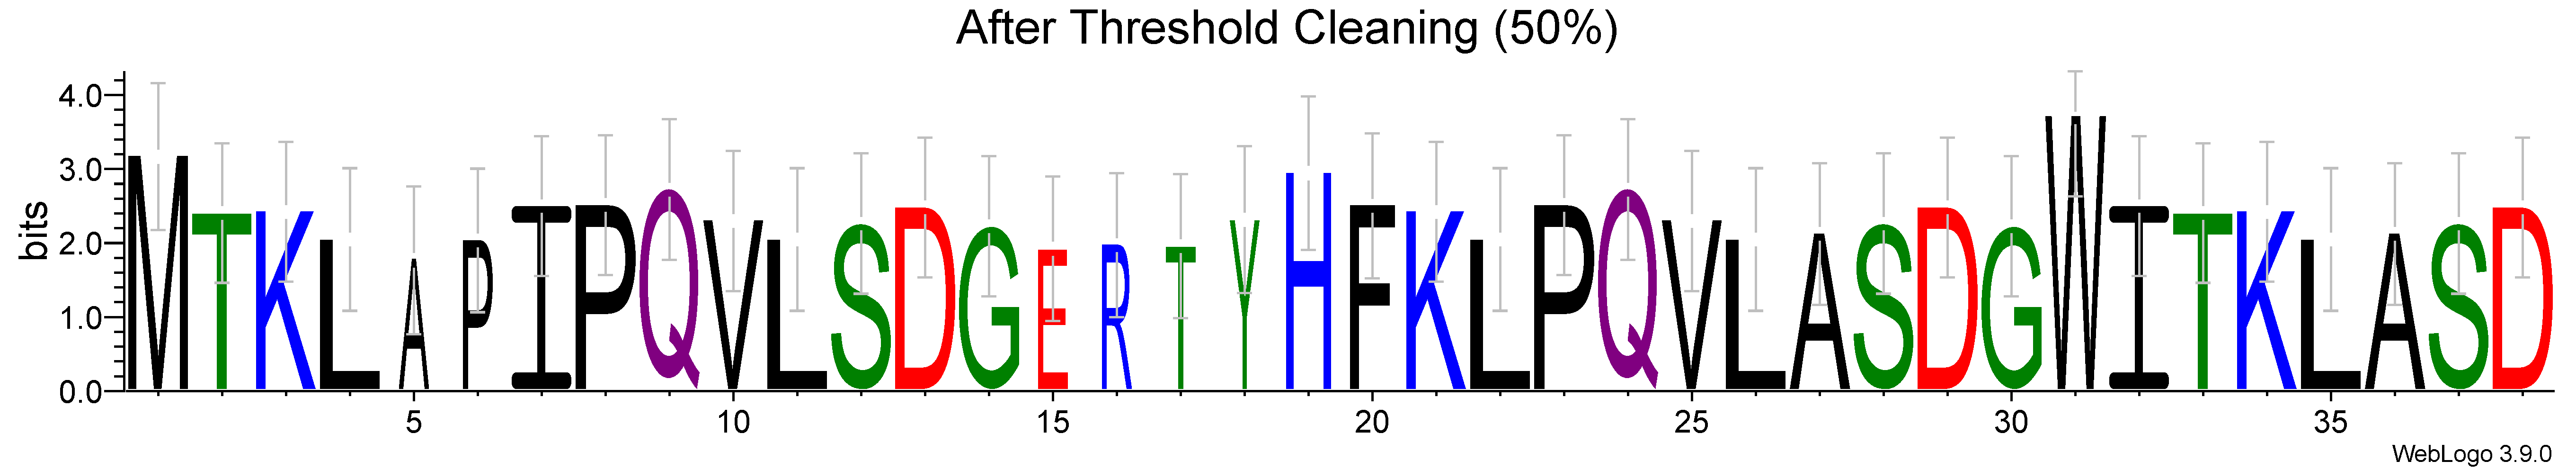


=== After Seed Cleaning ===


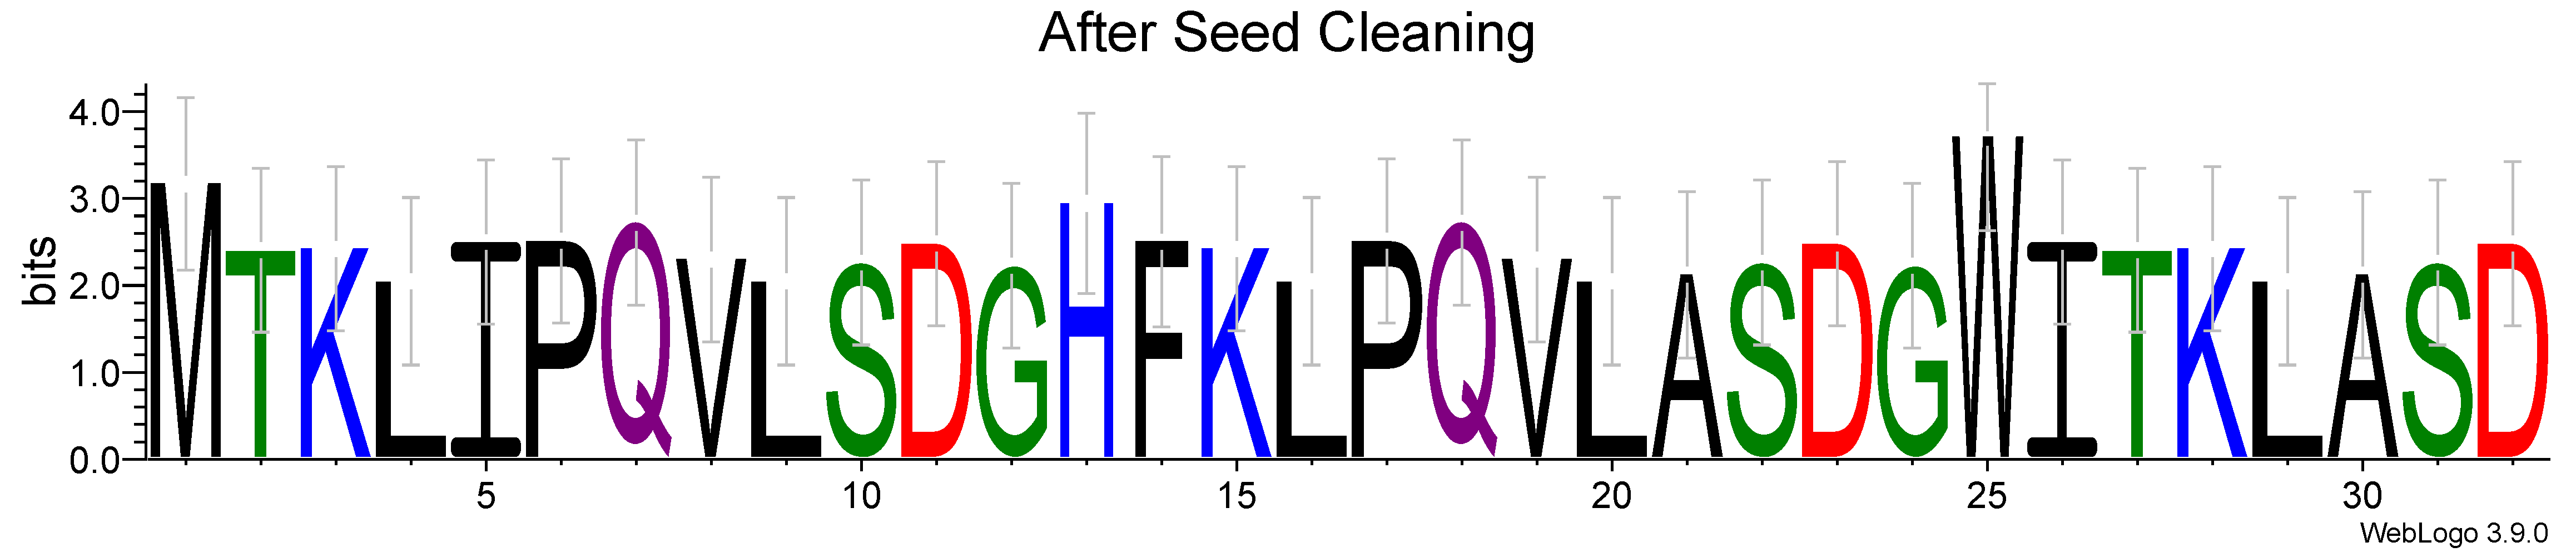


=== After Entropy Cleaning ===


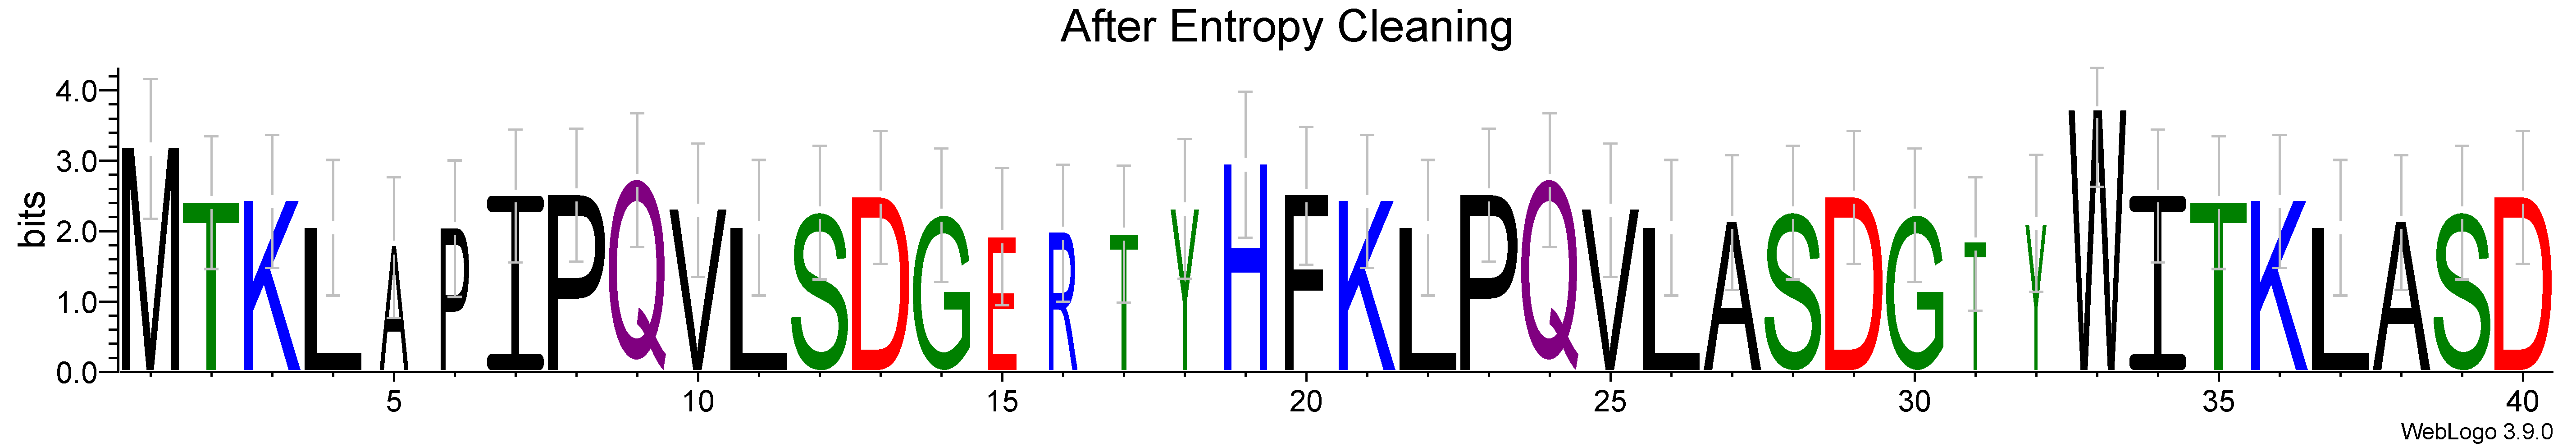

In [9]:
from IPython.display import Image, display

print("\n=== Original Alignment ===")
display(Image(filename=output_dir / 'weblogo_original.png'))

print("\n=== After Threshold Cleaning (50%) ===")
display(Image(filename=output_dir / 'weblogo_threshold50.png'))

print("\n=== After Seed Cleaning ===")
display(Image(filename=output_dir / 'weblogo_seed.png'))

print("\n=== After Entropy Cleaning ===")
display(Image(filename=output_dir / 'weblogo_entropy.png'))

## 7. Interactive Alignment Viewer

Create an interactive heatmap showing the alignment.

In [10]:
def create_alignment_heatmap(fasta_file, title='Alignment Heatmap'):
    """Create interactive alignment heatmap with Plotly."""
    sequences = list(SeqIO.parse(fasta_file, 'fasta'))
    
    # Convert sequences to numeric matrix (for coloring)
    # 0 = gap, 1-20 = amino acids
    aa_to_num = {aa: i+1 for i, aa in enumerate('ACDEFGHIKLMNPQRSTVWY')}
    aa_to_num['-'] = 0
    aa_to_num['.'] = 0
    
    matrix = []
    seq_names = []
    
    for seq in sequences:
        seq_names.append(seq.id)
        row = [aa_to_num.get(aa.upper(), 0) for aa in str(seq.seq)]
        matrix.append(row)
    
    # Create text matrix for hover
    text_matrix = [[str(seq.seq[i]) for i in range(len(seq.seq))] for seq in sequences]
    
    fig = go.Figure(data=go.Heatmap(
        z=matrix,
        x=[f'Pos {i+1}' for i in range(len(matrix[0]))],
        y=seq_names,
        text=text_matrix,
        hovertemplate='Sequence: %{y}<br>Position: %{x}<br>Residue: %{text}<extra></extra>',
        colorscale=[
            [0, 'lightgray'],      # Gaps
            [0.05, 'red'],         # Hydrophobic
            [0.3, 'blue'],         # Hydrophilic
            [0.6, 'green'],        # Polar
            [1, 'yellow']          # Special
        ],
        showscale=False
    ))
    
    fig.update_layout(
        title=title,
        xaxis_title='Alignment Position',
        yaxis_title='Sequence',
        height=max(400, len(sequences) * 25),
        width=min(1200, len(matrix[0]) * 15)
    )
    
    return fig

# Create interactive heatmaps
print("Creating interactive alignment viewers...\n")

fig_original = create_alignment_heatmap(input_file, 'Original Alignment')
fig_original.show()

fig_cleaned = create_alignment_heatmap(threshold_output, 'After Threshold Cleaning (50%)')
fig_cleaned.show()

Creating interactive alignment viewers...



## 8. Summary Statistics Comparison

In [11]:
# Create comparison table
comparison_data = {
    'Method': ['Original', 'Threshold (50%)', 'Seed (seq 0)', 'Entropy (max 2.0)'],
    'Alignment Length': [
        original_stats['alignment_length'],
        threshold_stats['alignment_length'],
        seed_stats['alignment_length'],
        entropy_stats['alignment_length']
    ],
    'Columns Removed': [
        0,
        original_stats['alignment_length'] - threshold_stats['alignment_length'],
        original_stats['alignment_length'] - seed_stats['alignment_length'],
        original_stats['alignment_length'] - entropy_stats['alignment_length']
    ],
    'Gap %': [
        f"{original_stats['overall_gap_percentage']:.1f}%",
        f"{threshold_stats['overall_gap_percentage']:.1f}%",
        f"{seed_stats['overall_gap_percentage']:.1f}%",
        f"{entropy_stats['overall_gap_percentage']:.1f}%"
    ]
}

df = pd.DataFrame(comparison_data)
print("\n=== Comparison Summary ===")
print(df.to_string(index=False))

# Save to CSV
df.to_csv(output_dir / 'comparison_summary.csv', index=False)
print(f"\nSummary saved to: {output_dir / 'comparison_summary.csv'}")


=== Comparison Summary ===
           Method  Alignment Length  Columns Removed Gap %
         Original                40                0 11.9%
  Threshold (50%)                38                2  9.2%
     Seed (seq 0)                32                8  1.6%
Entropy (max 2.0)                40                0 11.9%

Summary saved to: gapclean_output/comparison_summary.csv


## 9. File Size Comparison

In [12]:
import os

files = {
    'Original': input_file,
    'Threshold (50%)': threshold_output,
    'Seed': seed_output,
    'Entropy': entropy_output
}

print("\n=== File Sizes ===")
for name, filepath in files.items():
    size = os.path.getsize(filepath)
    print(f"{name:20s}: {size:6d} bytes ({size/1024:.2f} KB)")


=== File Sizes ===
Original            :    416 bytes (0.41 KB)
Threshold (50%)     :    400 bytes (0.39 KB)
Seed                :    352 bytes (0.34 KB)
Entropy             :    416 bytes (0.41 KB)


## 10. Export for Phylogenetics

The cleaned alignments can be used directly with phylogenetic tools like RAxML, IQ-TREE, or FastTree.

In [13]:
print("\n=== Ready for Phylogenetic Analysis ===")
print(f"\nCleaned alignment files:")
print(f"  - Threshold mode: {threshold_output}")
print(f"  - Seed mode: {seed_output}")
print(f"  - Entropy mode: {entropy_output}")

print("\nExample commands for phylogenetic analysis:")
print(f"\n# RAxML")
print(f"raxmlHPC -s {threshold_output} -n output -m PROTGAMMAAUTO -p 12345")

print(f"\n# IQ-TREE")
print(f"iqtree -s {threshold_output} -m MFP -bb 1000")

print(f"\n# FastTree")
print(f"FastTree {threshold_output} > tree.newick")


=== Ready for Phylogenetic Analysis ===

Cleaned alignment files:
  - Threshold mode: gapclean_output/cleaned_threshold50.fa
  - Seed mode: gapclean_output/cleaned_seed.fa
  - Entropy mode: gapclean_output/cleaned_entropy.fa

Example commands for phylogenetic analysis:

# RAxML
raxmlHPC -s gapclean_output/cleaned_threshold50.fa -n output -m PROTGAMMAAUTO -p 12345

# IQ-TREE
iqtree -s gapclean_output/cleaned_threshold50.fa -m MFP -bb 1000

# FastTree
FastTree gapclean_output/cleaned_threshold50.fa > tree.newick


## Summary

This notebook demonstrated:

1. Creating a sample alignment for testing
2. **Using GapClean's Python API** - one simple function call!
3. Running GapClean with three different modes (threshold, seed, entropy)
4. Analyzing alignment statistics before and after cleaning
5. Visualizing gap distribution across positions
6. Generating WebLogo sequence logos
7. Creating interactive alignment heatmaps with Plotly
8. Comparing results across different cleaning methods
9. Preparing cleaned alignments for downstream phylogenetic analysis

### Key Advantage: Simple Python API

GapClean v1.0.4 introduces a simple, high-level API:

```python
from gapclean import clean_alignment

# That's it! One import, one function call:
stats = clean_alignment(
    input_file='input.fa',
    output_file='output.fa',
    threshold=50  # or seed_index=0, or entropy_max=1.5
)

print(f"Removed {stats['columns_removed']} columns in {stats['elapsed_seconds']:.1f}s")
```

No temp file management, no subprocess calls, no complexity - just clean, Pythonic API design.

### Next Steps

- Try GapClean with your own alignments
- Experiment with different threshold values
- Use cleaned alignments for phylogenetic tree building
- Analyze conservation patterns with WebLogo
- Integrate GapClean into your Python workflows

### Learn More

- GapClean Documentation: https://arikat.github.io/GapClean/
- GitHub Repository: https://github.com/arikat/GapClean
- PyPI Package: https://pypi.org/project/gapclean/